In [1]:
import numpy as np
import pandas as pd
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': '...',
    'user': 'student',
    'database': 'simulator_20260920'
}

q = """
SELECT exp_group,
       user_id,
       sum(action = 'like') AS likes,
       sum(action = 'view') AS views,
       likes / views AS ctr
FROM {db}.feed_actions
WHERE toDate(time) BETWEEN '2026-08-28' AND '2026-09-03'
  AND exp_group IN (1, 2)
GROUP BY exp_group, user_id
"""
df = ph.read_clickhouse(q, connection=connection)

g1 = df[df.exp_group == 1]
g2 = df[df.exp_group == 2]

print(df.groupby('exp_group').agg(users=('user_id', 'count'),
                                  mean_ctr=('ctr', 'mean'),
                                  median_ctr=('ctr', 'median')))
print('Общий CTR (лайки/просмотры):')
print(df.groupby('exp_group')[['likes', 'views']].sum().eval('likes / views'))

           users  mean_ctr  median_ctr
exp_group                             
1          10020  0.216774    0.205882
2           9877  0.216102    0.153285
Общий CTR (лайки/просмотры):
exp_group
1    0.209604
2    0.200251
dtype: float64


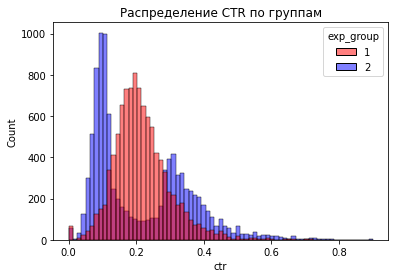

In [2]:
sns.histplot(data=df, x='ctr', hue='exp_group', palette=['r', 'b'], alpha=0.5, kde=False)
plt.title('Распределение CTR по группам')
plt.show()

In [3]:
print('t-тест:', stats.ttest_ind(g1.ctr, g2.ctr, equal_var=False))
print('Манн-Уитни:', stats.mannwhitneyu(g1.ctr, g2.ctr, alternative='two-sided'))

t-тест: Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)
Манн-Уитни: MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)


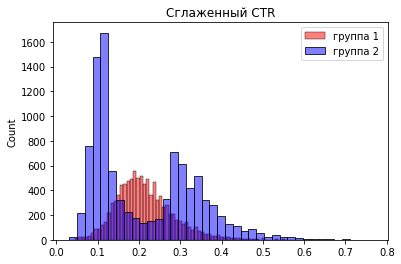

t-тест на сглаженном CTR: Ttest_indResult(statistic=1.9460491517027683, pvalue=0.05166679015318526)


In [4]:
def smoothed_ctr(likes, views, global_ctr, alpha=5):
    return (likes + alpha * global_ctr) / (views + alpha)

gctr1 = g1.likes.sum() / g1.views.sum()
gctr2 = g2.likes.sum() / g2.views.sum()

s1 = smoothed_ctr(g1.likes, g1.views, gctr1)
s2 = smoothed_ctr(g2.likes, g2.views, gctr2)

sns.histplot(s1, color='r', alpha=0.5, label='группа 1')
sns.histplot(s2, color='b', alpha=0.5, label='группа 2')
plt.legend(); plt.title('Сглаженный CTR'); plt.show()

print('t-тест на сглаженном CTR:', stats.ttest_ind(s1, s2, equal_var=False))

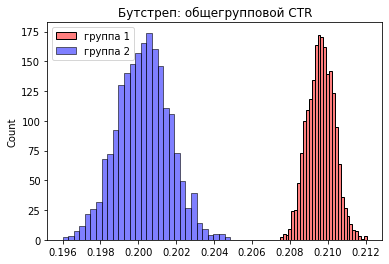

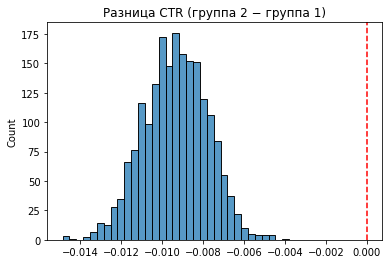

95% интервал разницы: [-0.01237672 -0.00649412]


In [5]:
def poisson_bootstrap(likes1, views1, likes2, views2, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    w1 = rng.poisson(1, (n, len(likes1)))
    w2 = rng.poisson(1, (n, len(likes2)))
    ctr1 = (w1 * likes1).sum(axis=1) / (w1 * views1).sum(axis=1)
    ctr2 = (w2 * likes2).sum(axis=1) / (w2 * views2).sum(axis=1)
    return ctr1, ctr2

b1, b2 = poisson_bootstrap(g1.likes.to_numpy(), g1.views.to_numpy(),
                           g2.likes.to_numpy(), g2.views.to_numpy())

sns.histplot(b1, color='r', alpha=0.5, label='группа 1')
sns.histplot(b2, color='b', alpha=0.5, label='группа 2')
plt.legend(); plt.title('Бутстреп: общегрупповой CTR'); plt.show()

diff = b2 - b1
sns.histplot(diff); plt.axvline(0, color='red', linestyle='--')
plt.title('Разница CTR (группа 2 − группа 1)'); plt.show()
print('95% интервал разницы:', np.percentile(diff, [2.5, 97.5]))

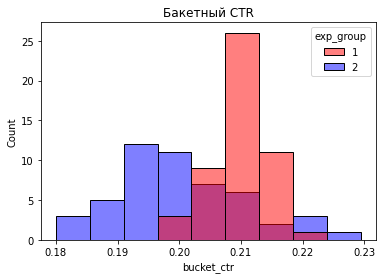

t-тест по бакетам: Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)
Манн-Уитни по бакетам: MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)


In [6]:
q_bucket = """
SELECT exp_group, bucket,
       sum(likes) / sum(views) AS bucket_ctr
FROM (
    SELECT exp_group,
           xxHash64(user_id) % 50 AS bucket,
           user_id,
           sum(action = 'like') AS likes,
           sum(action = 'view') AS views
    FROM {db}.feed_actions
    WHERE toDate(time) BETWEEN '2026-08-28' AND '2026-09-03'
      AND exp_group IN (1, 2)
    GROUP BY exp_group, bucket, user_id
)
GROUP BY exp_group, bucket
"""
bdf = ph.read_clickhouse(q_bucket, connection=connection)
bk1 = bdf[bdf.exp_group == 1].bucket_ctr
bk2 = bdf[bdf.exp_group == 2].bucket_ctr

sns.histplot(data=bdf, x='bucket_ctr', hue='exp_group', palette=['r', 'b'], alpha=0.5)
plt.title('Бакетный CTR'); plt.show()

print('t-тест по бакетам:', stats.ttest_ind(bk1, bk2, equal_var=False))
print('Манн-Уитни по бакетам:', stats.mannwhitneyu(bk1, bk2, alternative='two-sided'))

# Выводы по A/B-тесту нового алгоритма рекомендаций

Период: 2026-08-28 - 2026-09-03. Группа 1 - контроль, группа 2 - новый алгоритм.
Гипотеза: новый алгоритм увеличит CTR.

## 1. Результаты тестов

| Метод | Результат | Видит различие |
|---|---|---|
| t-тест | p = 0.685 | Нет |
| Тест Манна-Уитни | p = 4.6e-45 | Да |
| t-тест на сглаженном CTR (α=5) | p = 0.052 | На границе, формально нет |
| Пуассоновский бутстреп | 95% интервал разницы: [-0.0124; -0.0065] | Да, CTR в группе 2 ниже |
| t-тест по бакетам | p = 4.6e-07 | Да |
| Манн-Уитни по бакетам | p = 2.7e-07 | Да |

Общий CTR (лайки / просмотры): 0.2096 в контроле и 0.2003 в тесте — падение примерно на 0.9 п.п. (около 4.5% относительно).
Средний пользовательский CTR почти одинаков (0.2168 и 0.2161), а медианный упал с 0.206 до 0.153.

## 2. Почему тесты сработали по-разному

В тестовой группе распределение CTR стало двугорбым: большая часть пользователей сместилась к CTR около 0.1, меньшая - к CTR около 0.3. В контроле один горб около 0.2.

- **t-тест** сравнивает средние, а они почти совпали: пользователи с упавшим и выросшим CTR компенсировали друг друга. Кроме того, у двугорбого распределения большая дисперсия, что снижает чувствительность теста.
- **Тест Манна-Уитни** сравнивает ранги, то есть распределения целиком, поэтому изменение формы он обнаружил.
- **Сглаживание** убирает шум от пользователей с малым числом просмотров, но двугорбость сохраняется, поэтому результат остался на границе значимости.
- **Пуассоновский бутстреп и бакетное преобразование** работают с общегрупповым CTR, распределение которого близко к нормальному. Оба подхода показывают статистически значимое снижение CTR в тестовой группе.

## 3. Возможная причина

Алгоритм подошёл одной части аудитории и не подошёл другой, более многочисленной. Возможные объяснения:

- Алгоритм опирается на историю лайков: пользователям с богатой историей он подбирает релевантные посты, а пользователям с короткой историей  нерелевантные.
- Техническая проблема на части платформ (iOS или Android): рекомендации отображаются некорректно или повторяются.
- Лента стала менее разнообразной: любителям узкой темы это нравится, остальным быстро надоедает.

Проверить можно разбивкой CTR тестовой группы по сегментам: платформа, источник трафика, возраст, уровень активности.

## 4. Рекомендация

**Раскатывать новый алгоритм на всех пользователей не стоит.**

1. Гипотеза о росте CTR не подтвердилась: общий CTR статистически значимо снизился (бутстреп, оба бакетных теста).
2. Большинству пользователей стало хуже: медианный CTR упал с 0.206 до 0.153.
3. Аудитория раскололась на две части, и причина этого пока неизвестна, поэтому поведение алгоритма на всех пользователях непредсказуемо.

Следующий шаг - найти сегмент, в котором CTR вырос. Если он чётко определяется, можно провести новый тест только на этом сегменте.